# Lab 4 — Exercise: Exploring World Stock Market Indices

**ITCS 3162 — Introduction to Data Mining**

**Name:** Aleena Benny
**Date:** 6/7/2026

You'll explore daily prices for six major world stock indices over five years (2020–2024). Unlike penguins, this is **time-series data with a categorical dimension (ticker)** — you'll need to think about both the temporal structure and cross-sectional comparisons.

You have **two options** for loading the data — use whichever you prefer:

- **Option A (default):** Load the included `world_indices.csv` — pre-built, works offline, gives consistent results.
- **Option B (live fetch):** Download fresh data directly from Yahoo Finance using the `yfinance` library. This is how real analysts pull market data, but it requires internet and Yahoo's API can be flaky.

Both options produce a DataFrame with the same columns, so the rest of the notebook works identically.

| Column | Notes |
|---|---|
| `Date` | Trading day |
| `Ticker` | Yahoo Finance symbol (e.g. `^GSPC` for S&P 500) |
| `Name` | Full index name |
| `Country` | Country |
| `Open`, `High`, `Low`, `Close` | Daily prices |
| `Volume` | Trading volume (has some missing values) |

When you're done, **Restart & Run All**, download as `.ipynb`, and submit via Canvas.


## Setup — imports


In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

## Load the data — pick ONE option

Set `USE_LIVE_FETCH = False` for the default CSV (recommended), or `True` to try the live yfinance API. Then run the cell below it.


In [21]:
USE_LIVE_FETCH = True   # set to True to pull fresh data from Yahoo Finance

### Option A — Load the included CSV (runs when `USE_LIVE_FETCH = False`)
### Option B — Live fetch from Yahoo Finance (runs when `USE_LIVE_FETCH = True`)

The cell below handles both. Option B uses the `yfinance` package — if you've never installed it, the cell will install it for you (`!pip install yfinance`). If the fetch fails (network down, API rate-limit, etc.), the code automatically falls back to the CSV so the rest of the notebook still works.


In [22]:
if USE_LIVE_FETCH:
    tickers_meta = {
        "^GSPC":  ("S&P 500",                      "USA"),
        "^DJI":   ("Dow Jones Industrial Average", "USA"),
        "^IXIC":  ("NASDAQ Composite",             "USA"),
        "^FTSE":  ("FTSE 100",                     "United Kingdom"),
        "^N225":  ("Nikkei 225",                   "Japan"),
        "^GDAXI": ("DAX",                          "Germany"),
    }

    try:
        # Install yfinance if it isn't already available. The --break-system-packages
        # flag is needed on some Linux setups (including Colab in some configurations).
        try:
            import yfinance as yf
        except ImportError:
            import sys, subprocess
            try:
                subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "yfinance"])
            except subprocess.CalledProcessError:
                subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                                       "--break-system-packages", "yfinance"])
            import yfinance as yf

        # auto_adjust=True gives adjusted prices; group_by='ticker' returns one
        # block per symbol so it's easy to flatten into long format.
        raw = yf.download(
            list(tickers_meta.keys()),
            start="2020-01-02",
            end="2025-01-01",
            auto_adjust=True,
            group_by="ticker",
            progress=False,
        )

        # Flatten the wide MultiIndex DataFrame into long format
        frames = []
        for tk, (name, country) in tickers_meta.items():
            sub = raw[tk].copy().reset_index()
            sub["Ticker"]  = tk
            sub["Name"]    = name
            sub["Country"] = country
            frames.append(sub[["Date","Ticker","Name","Country","Open","High","Low","Close","Volume"]])
        df = pd.concat(frames, ignore_index=True).dropna(subset=["Close"])

        # yfinance returns an empty frame (not an error) when blocked or rate-limited.
        # Treat an empty result as a failure so we fall back to the CSV.
        if len(df) == 0:
            raise RuntimeError("yfinance returned no rows (likely network-blocked or rate-limited)")

        print(f"Live fetch succeeded — {df.shape[0]:,} rows from Yahoo Finance.")
    except Exception as e:
        print(f"Live fetch failed ({type(e).__name__}: {e}). Falling back to CSV.")
        df = pd.read_csv("world_indices.csv", parse_dates=["Date"])
else:
    df = pd.read_csv("world_indices.csv", parse_dates=["Date"])
    print(f"Loaded CSV — {df.shape[0]:,} rows.")

print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()

Live fetch succeeded — 7,532 rows from Yahoo Finance.
Date range: 2020-01-02 to 2024-12-31


Price,Date,Ticker,Name,Country,Open,High,Low,Close,Volume
0,2020-01-02,^GSPC,S&P 500,USA,3244.669922,3258.139893,3235.530029,3257.850098,3.459930e+09
1,2020-01-03,^GSPC,S&P 500,USA,3226.360107,3246.149902,3222.340088,3234.850098,3.484700e+09
2,2020-01-06,^GSPC,S&P 500,USA,3217.550049,3246.840088,3214.639893,3246.280029,3.702460e+09
3,2020-01-07,^GSPC,S&P 500,USA,3241.860107,3244.909912,3232.429932,3237.179932,3.435910e+09
4,2020-01-08,^GSPC,S&P 500,USA,3238.590088,3267.070068,3236.669922,3253.050049,3.726840e+09


## Exercise 1 — Initial profile (10 pts)

In the cell below:
1. Print `df.info()`
2. Print the count of rows for each `Ticker`
3. Print the count of missing values per column

Then answer the questions in the next markdown cell.


In [23]:
# TODO: info, rows per ticker, missing per column
# 1. DataFrame info
df.info()

print("\nRows per ticker:")
print(df["Ticker"].value_counts())

print("\nMissing values per column:")
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 7532 entries, 0 to 7810
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     7532 non-null   datetime64[ns]
 1   Ticker   7532 non-null   object        
 2   Name     7532 non-null   object        
 3   Country  7532 non-null   object        
 4   Open     7532 non-null   float64       
 5   High     7532 non-null   float64       
 6   Low      7532 non-null   float64       
 7   Close    7532 non-null   float64       
 8   Volume   7532 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(3)
memory usage: 588.4+ KB

Rows per ticker:
Ticker
^GDAXI    1275
^FTSE     1261
^DJI      1258
^GSPC     1258
^IXIC     1258
^N225     1222
Name: count, dtype: int64

Missing values per column:
Price
Date       0
Ticker     0
Name       0
Country    0
Open       0
High       0
Low        0
Close      0
Volume     0
dtype: int64


**Answers:**
1. Do all six indices have the same number of rows? Why might they differ?
2. Which column has the most missing values? What's a plausible real-world reason?

YOUR ANSWERS:
1. No, all six indices may not have the exact same number of rows. These are stock market indices from different countries, so their markets follow different trading calendars. Holidays, market closures, and missing trading days can cause some indices to have fewer rows than others.

2. The column with the most missing values is likely `Volume`. Trading volume is not always reported consistently for market indices, especially across different countries and data sources. Some indices may track price movement but not have good daily volume data available.



## Exercise 2 — Numeric summary by ticker (10 pts)

Produce a table where each row is one ticker, with columns:
- `mean_close`, `std_close`, `min_close`, `max_close`

Round to 2 decimals. Sort by `mean_close` descending.


In [24]:
# TODO: groupby summary by Ticker
summary = (
    df.groupby("Ticker")["Close"]
      .agg(
          mean_close="mean",
          std_close="std",
          min_close="min",
          max_close="max"
      )
      .round(2)
      .sort_values("mean_close", ascending=False)
)

summary

,mean_close,std_close,min_close,max_close
Ticker,,,,
^DJI,33652.08,4671.36,18591.93,45014.04
^N225,29601.85,5422.84,16552.83,42224.02
^GDAXI,15094.15,2201.69,8441.71,20426.27
^IXIC,13403.60,2662.70,6860.67,20173.89
^FTSE,7265.56,694.76,4993.90,8445.80
^GSPC,4259.61,767.45,2237.40,6090.27


## Exercise 3 — Time series plot (15 pts)

Make a single line plot showing `Close` over `Date`, one line per ticker.

Hint: `sns.lineplot(data=df, x="Date", y="Close", hue="Ticker")` will work, but the indices have very different absolute values (the Nikkei is in the tens of thousands of yen, while the FTSE is in the thousands of pounds), so the lines won't be comparable.

**Fix this** by normalizing each ticker so its first close = 100. This gives a fair comparison of returns. Steps:

1. Sort by Date within each ticker.
2. For each ticker, compute `Close_normalized = Close / first_close * 100`.
3. Plot `Close_normalized` over `Date`, colored by ticker.


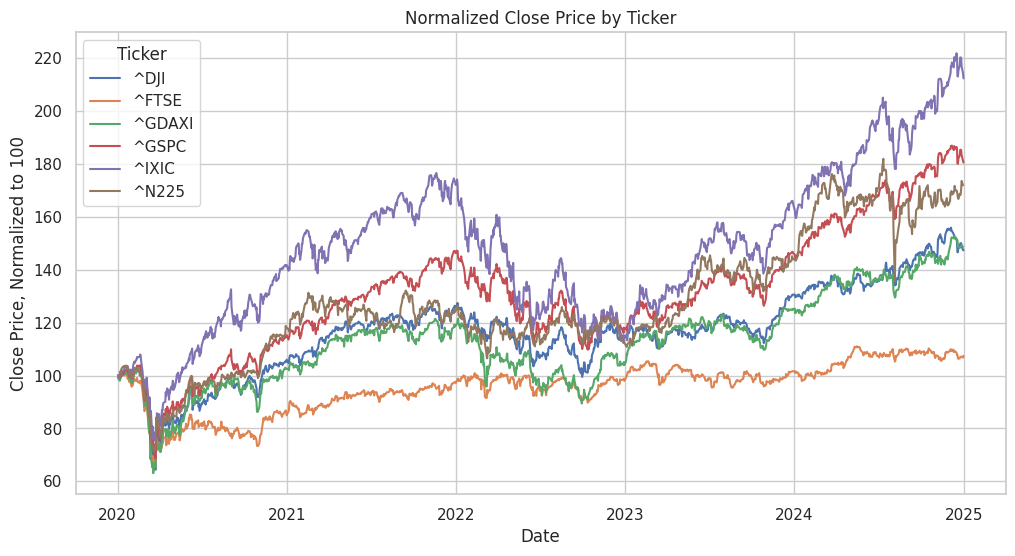

In [25]:
# TODO: compute normalized close
# Sort by Ticker and Date
df = df.sort_values(["Ticker", "Date"])

# Get the first close value for each ticker
first_close = df.groupby("Ticker")["Close"].transform("first")

# Normalize so each ticker starts at 100
df["Close_normalized"] = df["Close"] / first_close * 100

df.head()

# TODO: line plot
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="Date",
    y="Close_normalized",
    hue="Ticker",
    ax=ax
)

ax.set_title("Normalized Close Price by Ticker")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price, Normalized to 100")
plt.show()

## Exercise 4 — Daily returns distribution (15 pts)

Compute the **daily percent return** for each ticker: `return = (Close - prev_Close) / prev_Close`.

Hint: within each ticker, use `groupby("Ticker")["Close"].pct_change()`.

Then make a histogram (or KDE plot) showing the distribution of daily returns, with one panel per ticker (a *faceted* plot — `sns.displot` with `col="Ticker"` works well, and `col_wrap=3` to arrange them on two rows).


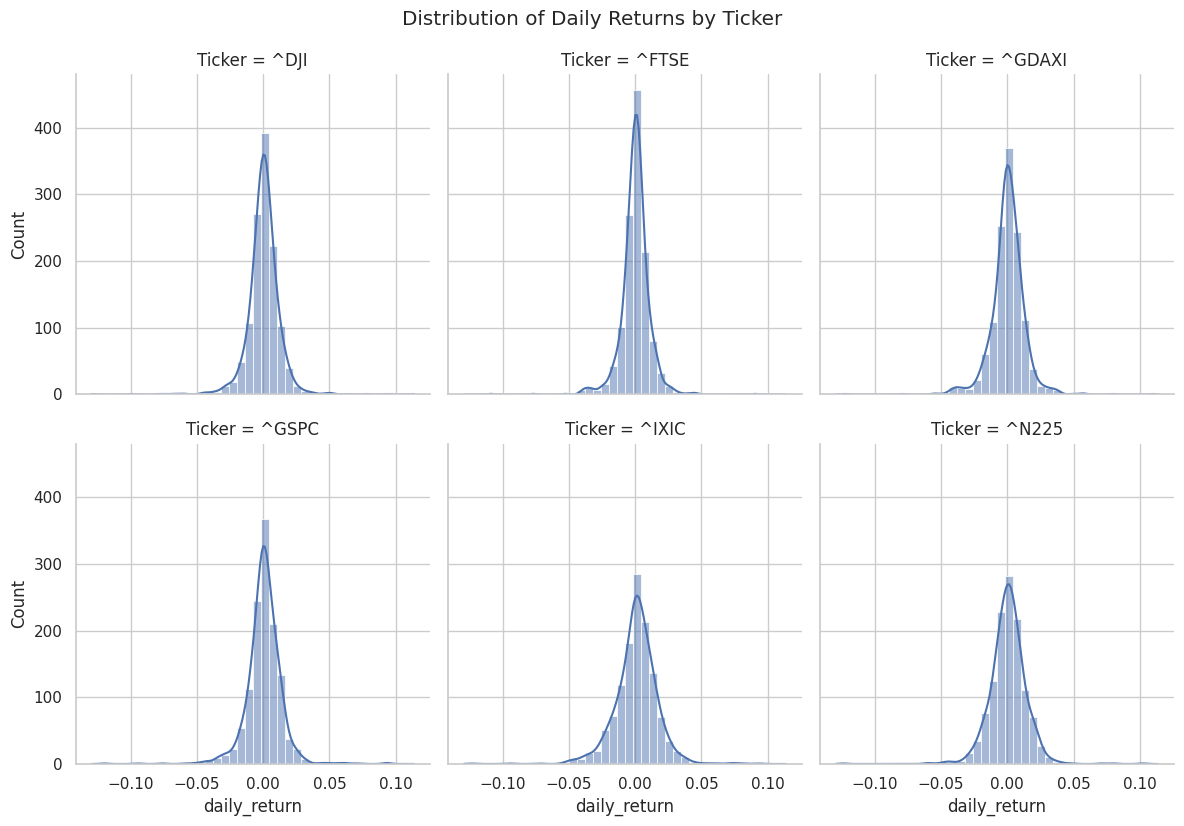

In [26]:
# TODO: daily returns
df = df.sort_values(["Ticker", "Date"])

df["daily_return"] = df.groupby("Ticker")["Close"].pct_change()

df[["Date", "Ticker", "Close", "daily_return"]].head(10)

# TODO: faceted distribution plot
sns.displot(
    data=df.dropna(subset=["daily_return"]),
    x="daily_return",
    col="Ticker",
    col_wrap=3,
    kde=True,
    bins=40,
    height=4
)

plt.suptitle("Distribution of Daily Returns by Ticker", y=1.03)
plt.show()

## Exercise 5 — Volatility comparison (15 pts)

The **standard deviation of daily returns** is a common (if simple) measure of an asset's risk / volatility.

1. Compute the standard deviation of daily returns per ticker.
2. Multiply by `√252` to annualize (252 trading days/year).
3. Display as a bar plot, sorted descending.
4. In the markdown cell, identify the most and least volatile index in this dataset.


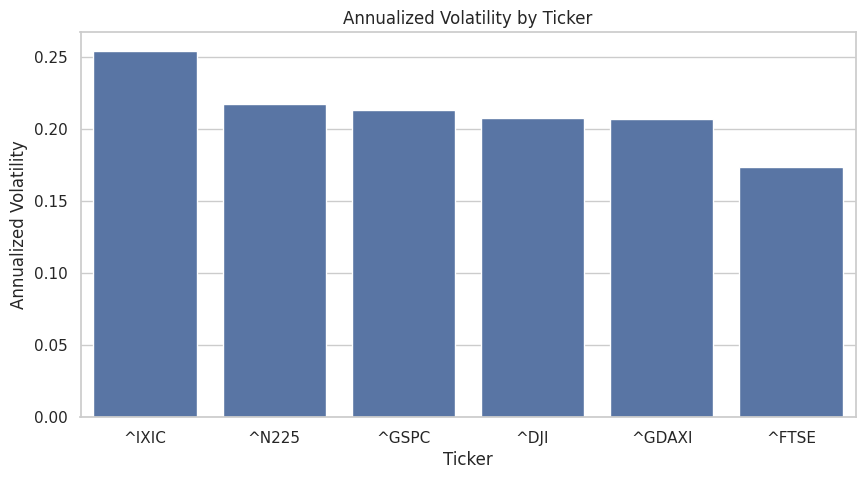

Most volatile: ^IXIC
Least volatile: ^FTSE


In [27]:
# TODO: annualized volatility per ticker, bar plot
volatility = (
    df.groupby("Ticker")["daily_return"]
      .std()
      .mul(np.sqrt(252))
      .reset_index(name="annualized_volatility")
      .sort_values("annualized_volatility", ascending=False)
)

volatility
fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=volatility,
    x="Ticker",
    y="annualized_volatility",
    ax=ax
)

ax.set_title("Annualized Volatility by Ticker")
ax.set_xlabel("Ticker")
ax.set_ylabel("Annualized Volatility")
plt.show()
most_volatile = volatility.iloc[0]["Ticker"]
least_volatile = volatility.iloc[-1]["Ticker"]

print("Most volatile:", most_volatile)
print("Least volatile:", least_volatile)

**YOUR ANSWER:** Most volatile = ^IXIC, least volatile = ^FTSE.



## Exercise 6 — Correlation between indices (15 pts)

Do the world's stock markets move together? Compute a correlation matrix of **daily returns** between tickers, and visualize it as a heatmap with `annot=True`.

Hint: you'll need to **pivot** the data first so each ticker is a column. Use `df.pivot(index="Date", columns="Ticker", values="Close").pct_change()`.


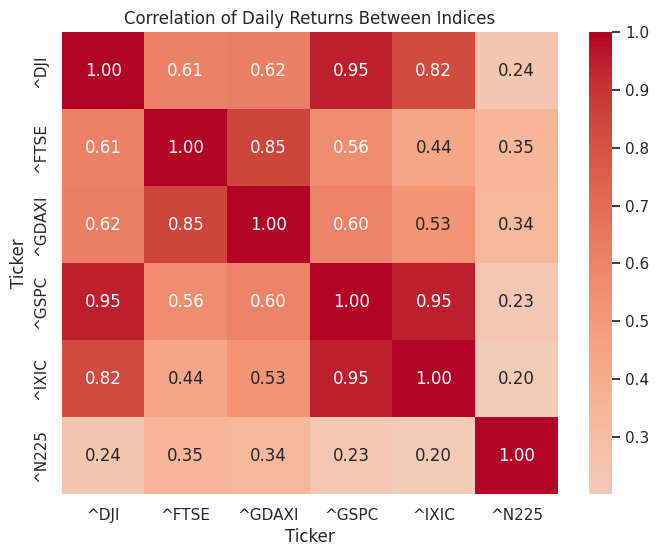

Most correlated pair: ('^DJI', '^GSPC') = 0.95
Most weakly correlated pair: ('^IXIC', '^N225') = 0.2


In [28]:
# TODO: pivot, compute returns, correlation, heatmap

# Pivot so each ticker becomes a column
close_pivot = df.pivot(index="Date", columns="Ticker", values="Close")

# Compute daily returns for each ticker
# fill_method=None avoids the FutureWarning
returns_pivot = close_pivot.pct_change(fill_method=None)

# Correlation matrix of daily returns
corr_matrix = returns_pivot.corr()

corr_matrix

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    ax=ax
)

ax.set_title("Correlation of Daily Returns Between Indices")
plt.show()
# Find strongest and weakest correlations, excluding self-correlations
corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_stack = corr_pairs.stack()

most_correlated = corr_stack.idxmax()
weakest_correlated = corr_stack.idxmin()

most_value = corr_stack.max()
weakest_value = corr_stack.min()

print("Most correlated pair:", most_correlated, "=", round(most_value, 3))
print("Most weakly correlated pair:", weakest_correlated, "=", round(weakest_value, 3))


\**YOUR ANSWER:** Which pair of indices is most correlated? Most weakly correlated? Does the geographic pattern make sense?

**YOUR ANSWER:** The most correlated pair is `^DJI` and `^GSPC`, with a correlation of 0.95. The most weakly correlated pair is `^IXIC` and `^N225`, with a correlation of 0.20. The geographic pattern makes sense because the Dow Jones and S&P 500 are both U.S. indices, so they are affected by many of the same economic conditions, market news, and investor behavior. The NASDAQ and Nikkei are from different countries and regions, so their weaker correlation makes sense because they may respond differently to local events, time zones, currencies, and economic conditions.

## Exercise 7 — Find the worst day (10 pts)

For each ticker, find the date of its **worst daily return** in the dataset. Display ticker, date, and return.

Then in the markdown cell, comment on whether the dates cluster around a common event.


In [29]:
# TODO: worst day per ticker
# TODO: worst day per ticker

# Make sure data is sorted
df = df.sort_values(["Ticker", "Date"])

# Compute daily returns if not already done
df["daily_return"] = df.groupby("Ticker")["Close"].pct_change()

# Find the worst daily return for each ticker
worst_days = df.loc[
    df.groupby("Ticker")["daily_return"].idxmin(),
    ["Ticker", "Name", "Date", "daily_return"]
].sort_values("daily_return")

# Display return as a percent for easier reading
worst_days["daily_return_percent"] = (worst_days["daily_return"] * 100).round(2)

worst_days

Price,Ticker,Name,Date,daily_return,daily_return_percent
1354,^DJI,Dow Jones Industrial Average,2020-03-16,-0.129265,-12.93
6403,^N225,Nikkei 225,2024-08-05,-0.123958,-12.40
2656,^IXIC,NASDAQ Composite,2020-03-16,-0.123213,-12.32
6560,^GDAXI,DAX,2020-03-12,-0.122386,-12.24
52,^GSPC,S&P 500,2020-03-16,-0.119841,-11.98
3956,^FTSE,FTSE 100,2020-03-12,-0.108738,-10.87


**YOUR ANSWER:** Are the worst days clustered? What might explain that?

Most of the worst days are clustered around March 2020. The Dow Jones, NASDAQ, S&P 500, DAX, and FTSE all had their worst daily returns on either March 12 or March 16, 2020, which likely reflects the early COVID-19 market crash. Global uncertainty, shutdowns, and fears about the economy caused major stock markets to drop sharply around the same time. The Nikkei 225 is the exception because its worst day was August 5, 2024, so not every index’s worst day came from the same event.


## Exercise 8 — Reflection (10 pts)

In 4–6 sentences:
1. Compare the EDA workflow on this dataset (time-series, multiple entities) to the one on penguins (cross-sectional, single observation per row). What changed?
2. Name one **modeling question** this exploration would help you set up. (E.g., "Predict whether the S&P will close up tomorrow given recent returns of European indices.")

YOUR ANSWER:

This dataset felt different from the penguins dataset because the order of the data actually matters here. For penguins, each row was just one penguin, so I was mainly comparing measurements across species. For the stock index data, I had to pay attention to time by sorting by date, grouping by ticker, normalizing prices, and calculating daily returns. I also had to compare how different markets moved during the same time period, so volatility and correlation became more important. One modeling question this exploration could help set up is: can we predict whether the S&P 500 will close higher tomorrow based on recent returns from other global indices?

## Submission checklist

- [ ] Name and date filled in
- [ ] All TODO cells completed and run
- [ ] All `YOUR ANSWER` prompts replaced
- [ ] **Restart & Run All** completes without errors
- [ ] Downloaded as `.ipynb` and uploaded to Canvas
